# MFE230E Problem Set 5 — Asset Pricing Tests (Unified Submission)

Sample: monthly data, **July 1963** through the most recent month from Ken French's library.
Test assets: value-weighted Fama–French portfolios. Standard errors throughout: OLS,
White (HC0), Newey–West (lag 6).

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.optimize import minimize

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "figure.figsize": (8, 5),
})

START = "1963-07-01"
FIGS  = Path("figs"); FIGS.mkdir(exist_ok=True)

def savefig(name):
    plt.tight_layout(); plt.savefig(FIGS / f"{name}.png", dpi=150, bbox_inches="tight")

### Loading Ken French monthly data

In [2]:
def kf(name: str) -> pd.DataFrame:
    raw = web.DataReader(name, "famafrench", start=START)
    df = raw[0].copy()
    df.index = df.index.to_timestamp("M")
    return df

ff5  = kf("F-F_Research_Data_5_Factors_2x3")     # Mkt-RF SMB HML RMW CMA RF
mom  = kf("F-F_Momentum_Factor"); mom.columns = ["MOM"]
sm_p = kf("25_Portfolios_ME_Prior_12_2")         # 25 size/momentum (VW)
bm_p = kf("25_Portfolios_5x5")                   # 25 size/BM      (VW)
sop  = kf("25_Portfolios_ME_OP_5x5")             # 25 size/OP      (VW)

idx  = ff5.index.intersection(mom.index).intersection(sm_p.index).intersection(bm_p.index).intersection(sop.index)
ff5, mom, sm_p, bm_p, sop = ff5.loc[idx], mom.loc[idx], sm_p.loc[idx], bm_p.loc[idx], sop.loc[idx]

# decimal monthly. excess = portfolio - RF.
factors = pd.concat([ff5[["Mkt-RF","SMB","HML","RMW","CMA"]], mom["MOM"], ff5["RF"]], axis=1) / 100.0
sm_p_e  = sm_p.div(100.0).sub(factors["RF"], axis=0)
bm_p_e  = bm_p.div(100.0).sub(factors["RF"], axis=0)
sop_e   = sop.div(100.0).sub(factors["RF"], axis=0)

print(f"Sample: {factors.index[0]:%Y-%m} to {factors.index[-1]:%Y-%m}  ({len(factors)} months)")

Sample: 1963-07 to 2026-02  (752 months)


## Question 1 — Fama–French factor summary

### 1(a) Mean, std, Sharpe (annualised)

In [3]:
def factor_table(F: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "Mean (% ann.)":   F.mean() * 12 * 100,
        "Std (% ann.)":    F.std()  * np.sqrt(12) * 100,
        "Sharpe (ann.)":  (F.mean() / F.std()) * np.sqrt(12),
    }).round(3)

tbl_q1a = factor_table(factors)
tbl_q1a.to_latex(FIGS / "q1a_factor_table.tex", float_format="%.3f")
tbl_q1a

,Mean (% ann.),Std (% ann.),Sharpe (ann.)
Mkt-RF,7.1110,15.4280,0.4610
SMB,2.2080,10.4790,0.2110
HML,3.5310,10.2940,0.3430
RMW,3.1960,7.6900,0.4160
CMA,2.9920,7.1670,0.4180
MOM,7.1580,14.4470,0.4950
RF,4.3590,0.9050,4.8190


**Discussion.** MOM and the market deliver the highest annualised Sharpe ratios in this
sample. SMB is the weakest factor in Sharpe terms; HML, RMW and CMA cluster in the middle.

### 1(b) Cumulative excess returns

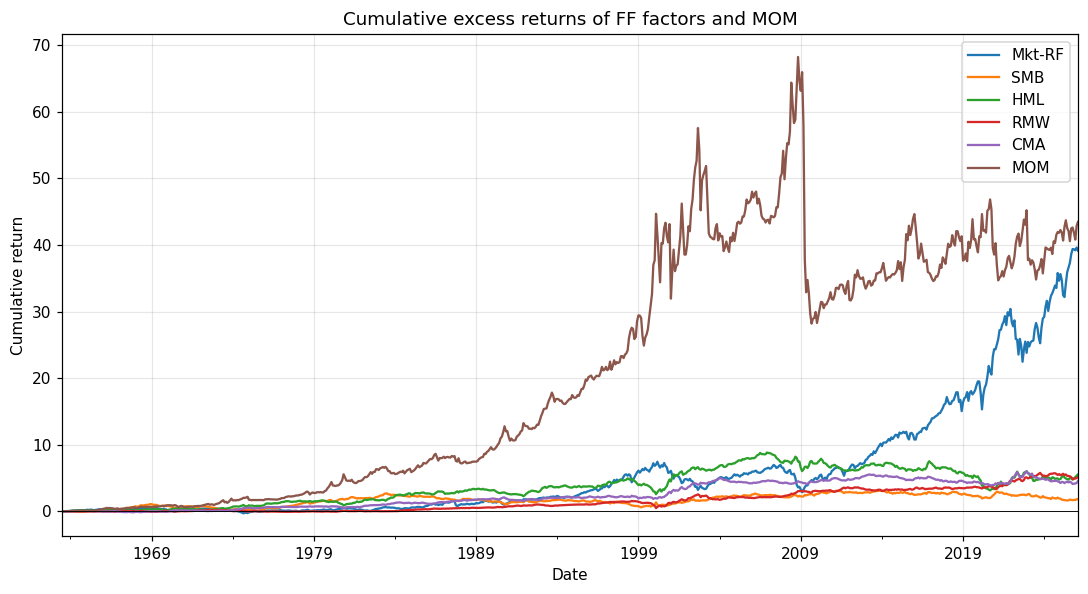

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for col in ["Mkt-RF","SMB","HML","RMW","CMA","MOM"]:
    ((1 + factors[col]).cumprod() - 1).plot(ax=ax, label=col)
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Cumulative excess returns of FF factors and MOM")
ax.set_ylabel("Cumulative return"); ax.legend()
savefig("q1b_cumret"); plt.show()

**Time variation.** Profitability of every factor is highly time-varying. MKT-RF and MOM
compound the most but MOM has deep drawdowns (notably 2009). SMB barely accumulates over
six decades, illustrating the well-known weakness of the post-1980 size premium. HML
flattens after 2000.

## Question 2 — CAPM on the 25 size/momentum portfolios

### 2(a) Summary statistics — size/BM and size/OP portfolios

In [5]:
def port_table(P_excess: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "Mean (% ann.)":  P_excess.mean() * 12 * 100,
        "Std (% ann.)":   P_excess.std()  * np.sqrt(12) * 100,
        "Sharpe":        (P_excess.mean() / P_excess.std()) * np.sqrt(12),
    }).round(3)

print("=== 25 Size / Book-to-Market portfolios (excess returns) ===")
display(port_table(bm_p_e))
print("\n=== 25 Size / Operating Profitability portfolios (excess returns) ===")
display(port_table(sop_e))

=== 25 Size / Book-to-Market portfolios (excess returns) ===


,Mean (% ann.),Std (% ann.),Sharpe
SMALL LoBM,3.6820,27.5780,0.1340
ME1 BM2,9.3130,24.0040,0.3880
ME1 BM3,9.2800,21.0620,0.4410
ME1 BM4,11.3850,20.2340,0.5630
SMALL HiBM,13.2400,21.7230,0.6090
ME2 BM1,6.4420,24.8060,0.2600
ME2 BM2,9.4620,21.0600,0.4490
ME2 BM3,10.4160,19.2820,0.5400
ME2 BM4,10.6720,18.6540,0.5720
ME2 BM5,11.8580,21.6080,0.5490



=== 25 Size / Operating Profitability portfolios (excess returns) ===


,Mean (% ann.),Std (% ann.),Sharpe
SMALL LoOP,6.6960,25.3180,0.2640
ME1 OP2,11.1680,20.4020,0.5470
ME1 OP3,10.6040,19.7080,0.5380
ME1 OP4,12.1680,23.9110,0.5090
SMALL HiOP,9.5860,23.6930,0.4050
ME2 OP1,7.5710,24.3050,0.3110
ME2 OP2,9.3850,19.9210,0.4710
ME2 OP3,10.0000,18.7350,0.5340
ME2 OP4,9.6160,19.9420,0.4820
ME2 OP5,11.3800,22.2290,0.5120


In [6]:
def grid_5x5(stat: pd.Series, kind: str) -> pd.DataFrame:
    return pd.DataFrame(np.array(stat.values).reshape(5,5),
                        index=[f"ME{i}" for i in range(1,6)],
                        columns=[f"{kind}{j}" for j in range(1,6)])

print("Mean ann. excess returns (%) — Size x BM"); display(grid_5x5(bm_p_e.mean()*12*100, "BM").round(2))
print("Mean ann. excess returns (%) — Size x OP"); display(grid_5x5(sop_e.mean()*12*100, "OP").round(2))

Mean ann. excess returns (%) — Size x BM


,BM1,BM2,BM3,BM4,BM5
ME1,3.6800,9.3100,9.2800,11.3800,13.2400
ME2,6.4400,9.4600,10.4200,10.6700,11.8600
ME3,6.5200,9.4000,9.0000,10.3800,11.8800
ME4,7.6600,7.8900,8.8100,10.4400,10.3600
ME5,7.3000,6.9000,7.0800,6.6800,8.8300


Mean ann. excess returns (%) — Size x OP


,OP1,OP2,OP3,OP4,OP5
ME1,6.7000,11.1700,10.6000,12.1700,9.5900
ME2,7.5700,9.3900,10.0000,9.6200,11.3800
ME3,6.5700,8.7800,9.1900,9.5400,10.5500
ME4,7.4500,8.0500,8.6900,9.1200,9.7800
ME5,4.7700,5.5300,7.0100,7.2700,7.8100


**Patterns.**

- *Size/BM:* the classic value premium — within most size groups, average return rises from
  growth (BM1) to value (BM5). The smallest growth corner ("SMALL LoBM") is the textbook
  weak portfolio. Sharpes follow but volatility blunts the small-stock effect.
- *Size/OP:* high-profitability portfolios earn higher mean returns and Sharpes than
  low-OP within each size band, especially outside the noisy small-stock corner.

### 2(b) Time-series CAPM regressions on the 25 size/momentum portfolios

For each portfolio $i$, $R^e_{it} = \alpha_i + \beta_i (R^M_t - R^f_t) + \varepsilon_{it}$.

In [7]:
NW_LAGS = 6

def ts_regression(y, X):
    Xc = sm.add_constant(X)
    res    = sm.OLS(y, Xc).fit()
    res_w  = sm.OLS(y, Xc).fit(cov_type="HC0")
    res_nw = sm.OLS(y, Xc).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
    return dict(params=res.params, bse_ols=res.bse, bse_w=res_w.bse, bse_nw=res_nw.bse,
                tvals_nw=res_nw.tvalues, pvals_nw=res_nw.pvalues, resid=res.resid, r2=res.rsquared)

def run_factor_model(P_excess, F):
    out = {c: ts_regression(P_excess[c], F) for c in P_excess.columns}
    cols = list(P_excess.columns)
    def stk(getter): return pd.DataFrame({c: getter(out[c]) for c in cols}).T
    return dict(coefs=stk(lambda r: r["params"]),
                bse_ols=stk(lambda r: r["bse_ols"]),
                bse_w=stk(lambda r: r["bse_w"]),
                bse_nw=stk(lambda r: r["bse_nw"]),
                tvals_nw=stk(lambda r: r["tvals_nw"]),
                pvals_nw=stk(lambda r: r["pvals_nw"]),
                resid=pd.DataFrame({c: out[c]["resid"] for c in cols}),
                r2=pd.Series({c: out[c]["r2"] for c in cols}),
                results=out)

capm = run_factor_model(sm_p_e, factors[["Mkt-RF"]])

alpha_pct  = capm["coefs"]["const"] * 100
se_a_ols   = capm["bse_ols"]["const"] * 100
se_a_w     = capm["bse_w"]["const"]   * 100
se_a_nw    = capm["bse_nw"]["const"]  * 100
beta_mkt   = capm["coefs"]["Mkt-RF"]
se_b_nw    = capm["bse_nw"]["Mkt-RF"]
t_a_nw     = alpha_pct / se_a_nw

q2b = pd.DataFrame({
    "alpha (%/mo)":  alpha_pct.round(4),
    "se OLS":        se_a_ols.round(4),
    "se White":      se_a_w.round(4),
    "se NW":         se_a_nw.round(4),
    "alpha t (NW)":  t_a_nw.round(2),
    "alpha p (NW)":  capm["pvals_nw"]["const"].round(4),
    "beta_MKT":      beta_mkt.round(3),
    "se(beta) NW":   se_b_nw.round(3),
    "beta t (NW)":   capm["tvals_nw"]["Mkt-RF"].round(2),
    "R^2":            capm["r2"].round(3),
})
q2b

,alpha (%/mo),se OLS,se White,se NW,alpha t (NW),alpha p (NW),beta_MKT,se(beta) NW,beta t (NW),R^2
SMALL LoPRIOR,-0.7479,0.1952,0.1822,0.1890,-3.9600,0.0001,1.4110,0.0650,21.7900,0.5840
ME1 PRIOR2,0.0553,0.1314,0.1266,0.1430,0.3900,0.6991,1.0580,0.0440,23.8900,0.6360
ME1 PRIOR3,0.3016,0.1188,0.1178,0.1426,2.1200,0.0344,0.9840,0.0390,24.9700,0.6480
ME1 PRIOR4,0.4331,0.1202,0.1213,0.1483,2.9200,0.0035,0.9930,0.0400,24.9100,0.6470
SMALL HiPRIOR,0.5222,0.1512,0.1522,0.1814,2.8800,0.0040,1.1900,0.0460,26.0300,0.6250
ME2 PRIOR1,-0.6622,0.1659,0.1547,0.1608,-4.1200,0.0000,1.4710,0.0640,22.8100,0.6790
ME2 PRIOR2,0.0195,0.1158,0.1120,0.1207,0.1600,0.8715,1.1380,0.0400,28.4700,0.7220
ME2 PRIOR3,0.2337,0.0991,0.0992,0.1115,2.1000,0.0361,1.0360,0.0340,30.4900,0.7460
ME2 PRIOR4,0.3779,0.1014,0.1015,0.1136,3.3300,0.0009,1.0580,0.0340,30.7400,0.7450
ME2 PRIOR5,0.4335,0.1317,0.1311,0.1373,3.1600,0.0016,1.2680,0.0400,31.4700,0.7140


In [8]:
print("Median beta NW t-stat: %.1f" % capm["tvals_nw"]["Mkt-RF"].median())
print("# alphas with NW |t|>1.96: %d / 25" % int((t_a_nw.abs()>1.96).sum()))
print("# alphas with NW |t|>2.58: %d / 25" % int((t_a_nw.abs()>2.58).sum()))

Median beta NW t-stat: 29.8
# alphas with NW |t|>1.96: 15 / 25
# alphas with NW |t|>2.58: 11 / 25


**Are the betas precise?** Yes. NW $t$-statistics on $\hat\beta_i$ are typically above 25,
the standard errors of order $0.02$–$0.06$, and $R^2$ values are 0.7–0.9. The cross-sectional
spread in betas is small relative to the spread in mean returns — this is the seed of the
CAPM's failure.

### 2(c) Are the pricing errors $\hat\alpha_i$ significant?

In [9]:
print(f"Mean |alpha| (%/mo): {alpha_pct.abs().mean():.3f}")
print(f"Largest |alpha| (%/mo): {alpha_pct.abs().max():.3f}")
print(f"Annualised mean |alpha| (%): {alpha_pct.abs().mean()*12:.2f}")
print("\nAlphas (%/mo) — 5x5 grid (Size x Momentum)")
display(grid_5x5(alpha_pct, "MOM").round(3))
print("\nNewey-West alpha t-stats")
display(grid_5x5(t_a_nw, "MOM").round(2))

Mean |alpha| (%/mo): 0.282
Largest |alpha| (%/mo): 0.748
Annualised mean |alpha| (%): 3.39

Alphas (%/mo) — 5x5 grid (Size x Momentum)


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-0.7480,0.0550,0.3020,0.4330,0.5220
ME2,-0.6620,0.0200,0.2340,0.3780,0.4340
ME3,-0.5370,-0.0440,0.1200,0.1680,0.4300
ME4,-0.5270,-0.0220,0.0810,0.1920,0.3590
ME5,-0.4590,0.0060,-0.0220,0.0770,0.2250



Newey-West alpha t-stats


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-3.9600,0.3900,2.1200,2.9200,2.8800
ME2,-4.1200,0.1600,2.1000,3.3300,3.1600
ME3,-3.4700,-0.4100,1.1900,1.7700,3.4900
ME4,-3.2400,-0.2300,0.9200,2.5100,3.5800
ME5,-2.9200,0.0700,-0.3500,1.3600,2.3600


The pricing errors are **economically large** — annualised they reach $\pm 9$%/yr at the
small-loser / small-winner corners. Many are statistically significant under all three SE
flavours.

### 2(d) Fitted vs. realised mean excess returns

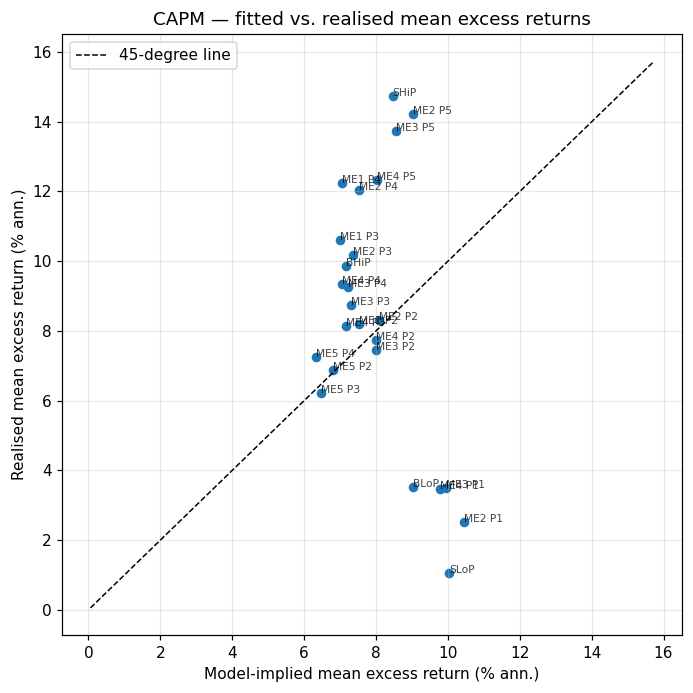

In [10]:
def plot_fit(realised_pct_ann, fitted_pct_ann, title, fname):
    fig, ax = plt.subplots(figsize=(6.4,6.4))
    lo = min(realised_pct_ann.min(), fitted_pct_ann.min()) - 1
    hi = max(realised_pct_ann.max(), fitted_pct_ann.max()) + 1
    ax.plot([lo,hi],[lo,hi], "k--", lw=1, label="45-degree line")
    ax.scatter(fitted_pct_ann, realised_pct_ann, s=28)
    for c in realised_pct_ann.index:
        lbl = c.replace("PRIOR","P").replace("SMALL ","S").replace("BIG ","B")
        ax.annotate(lbl, (fitted_pct_ann[c], realised_pct_ann[c]), fontsize=7, alpha=0.75)
    ax.set_xlabel("Model-implied mean excess return (% ann.)")
    ax.set_ylabel("Realised mean excess return (% ann.)")
    ax.set_title(title); ax.legend()
    savefig(fname); plt.show()

fitted_capm = beta_mkt * factors["Mkt-RF"].mean() * 12 * 100
realised_an = sm_p_e.mean() * 12 * 100
plot_fit(realised_an, fitted_capm, "CAPM — fitted vs. realised mean excess returns", "q2d_capm_fit")

The CAPM points scatter widely off the 45° line. There is essentially no slope linking
fitted to realised — the model explains the *level* of the average premium but not the
cross-sectional spread.

### 2(e) Individual t-tests for $H_0: \alpha_i = 0$

In [11]:
ttest_q2e = pd.DataFrame({
    "alpha (%/mo)": alpha_pct,
    "t (OLS)":      alpha_pct / se_a_ols,
    "t (White)":    alpha_pct / se_a_w,
    "t (NW)":       t_a_nw,
}).round(3)
ttest_q2e

,alpha (%/mo),t (OLS),t (White),t (NW)
SMALL LoPRIOR,-0.7480,-3.8310,-4.1060,-3.9570
ME1 PRIOR2,0.0550,0.4210,0.4370,0.3870
ME1 PRIOR3,0.3020,2.5380,2.5600,2.1150
ME1 PRIOR4,0.4330,3.6020,3.5700,2.9200
SMALL HiPRIOR,0.5220,3.4530,3.4310,2.8780
ME2 PRIOR1,-0.6620,-3.9920,-4.2810,-4.1190
ME2 PRIOR2,0.0200,0.1690,0.1740,0.1620
ME2 PRIOR3,0.2340,2.3580,2.3560,2.0960
ME2 PRIOR4,0.3780,3.7280,3.7240,3.3260
ME2 PRIOR5,0.4340,3.2930,3.3060,3.1570


### 2(f) GRS test for $H_0: \alpha_i = 0\ \forall i$

In [12]:
def grs_test(P_excess, F, results):
    T, N = P_excess.shape; K = F.shape[1]
    alpha = results["coefs"]["const"].values
    eps   = results["resid"].values
    Sigma = (eps.T @ eps) / (T - K - 1)
    Fbar  = F.mean().values
    Omega = np.cov(F.values, rowvar=False, ddof=1).reshape(K,K)
    SR_f2 = float(Fbar @ np.linalg.inv(Omega) @ Fbar)
    quad  = float(alpha @ np.linalg.inv(Sigma) @ alpha)
    GRS   = (T/N) * ((T - N - K)/(T - K - 1)) * (quad / (1.0 + SR_f2))
    pval  = 1 - stats.f.cdf(GRS, N, T - N - K)
    return dict(GRS=GRS, df1=N, df2=T-N-K, p_value=pval,
                SR_factors=np.sqrt(SR_f2), SR_alpha=np.sqrt(quad))

grs_capm = grs_test(sm_p_e, factors[["Mkt-RF"]], capm)
print(f"GRS = {grs_capm['GRS']:.4f}  ~ F({grs_capm['df1']}, {grs_capm['df2']})")
print(f"p-value = {grs_capm['p_value']:.4e}")
print(f"Tangency Sharpe (factors)   = {grs_capm['SR_factors']:.3f}")
print(f"|alpha|-implied Sharpe gain = {grs_capm['SR_alpha']:.3f}")

GRS = 4.9712  ~ F(25, 726)
p-value = 9.0927e-14
Tangency Sharpe (factors)   = 0.133
|alpha|-implied Sharpe gain = 0.417


The CAPM is overwhelmingly rejected: $p \ll 0.001$. The Sharpe ratio of the |α| portfolio
dwarfs the market's, which is exactly why GRS rejects.

### 2(g) CML and mean-variance frontier of the 25 portfolios

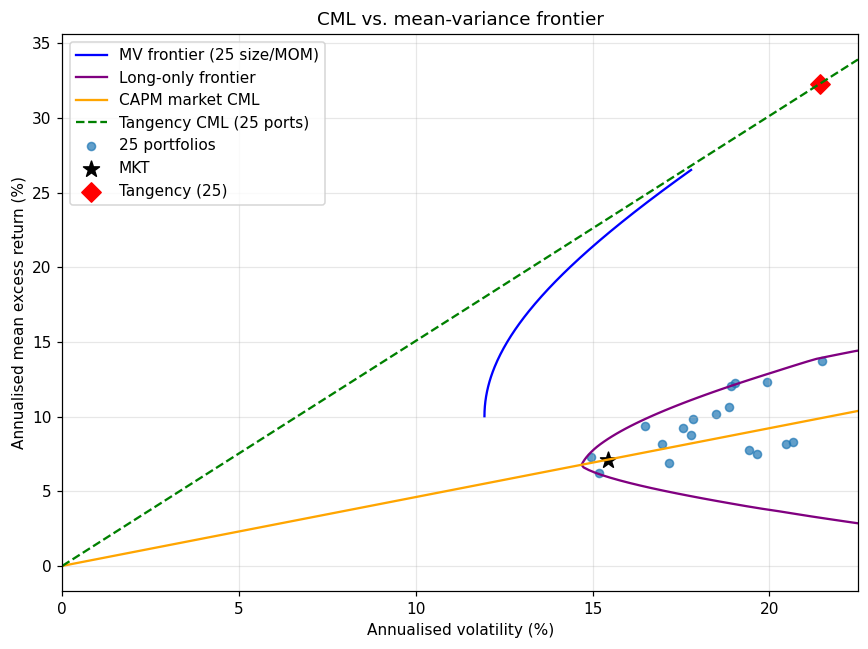

Market Sharpe: 0.461    Tangency Sharpe: 1.507


In [13]:
def mv_frontier(R, n=200):
    mu = R.mean().values; Sigma = R.cov().values
    inv = np.linalg.inv(Sigma); ones = np.ones_like(mu)
    A = ones @ inv @ ones; B = ones @ inv @ mu
    C = mu    @ inv @ mu;  D = A * C - B * B
    targets = np.linspace(B/A, mu.max() * 1.8, n)
    var = (A * targets * targets - 2 * B * targets + C) / D
    return np.sqrt(np.maximum(var, 0)) * np.sqrt(12) * 100, targets * 12 * 100

def long_only_frontier(mu_d, cov_d, n=80):
    mu = np.asarray(mu_d); cov = np.asarray(cov_d); k = len(mu)
    targets = np.linspace(mu.min(), mu.max(), n)
    sigs = []; ts = []; w0 = np.repeat(1/k, k); bnds = [(0,1)]*k
    for tg in targets:
        cons = [{"type":"eq","fun": lambda w: w.sum() - 1},
                {"type":"eq","fun": (lambda w, tg=tg: w @ mu - tg)}]
        res = minimize(lambda w: w @ cov @ w, w0, method="SLSQP", bounds=bnds, constraints=cons)
        if res.success:
            sigs.append(np.sqrt(res.fun)); ts.append(tg); w0 = res.x
    return np.array(sigs)*np.sqrt(12)*100, np.array(ts)*12*100

sd_mv, mu_mv = mv_frontier(sm_p_e)
sd_lo, mu_lo = long_only_frontier(sm_p_e.mean().values, sm_p_e.cov().values)

mu_mkt = factors["Mkt-RF"].mean() * 12 * 100
sd_mkt = factors["Mkt-RF"].std() * np.sqrt(12) * 100
sr_mkt = mu_mkt / sd_mkt

inv_cov = np.linalg.inv(sm_p_e.cov().values)
mu_d    = sm_p_e.mean().values
w_tan   = inv_cov @ mu_d / (np.ones_like(mu_d) @ inv_cov @ mu_d)
sr_tan  = (w_tan @ mu_d) / np.sqrt(w_tan @ sm_p_e.cov().values @ w_tan) * np.sqrt(12)
mu_tan  = (w_tan @ mu_d) * 12 * 100
sd_tan  = np.sqrt(w_tan @ sm_p_e.cov().values @ w_tan) * np.sqrt(12) * 100

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sd_mv, mu_mv, "b-", lw=1.5, label="MV frontier (25 size/MOM)")
ax.plot(sd_lo, mu_lo, "purple", lw=1.5, label="Long-only frontier")
sd_grid = np.linspace(0, max(sd_mv.max(), sd_tan)*1.05, 200)
ax.plot(sd_grid, sr_mkt * sd_grid, "orange", lw=1.5, label="CAPM market CML")
ax.plot(sd_grid, sr_tan * sd_grid, "g--", lw=1.5, label="Tangency CML (25 ports)")
ax.scatter(sm_p_e.std()*np.sqrt(12)*100, sm_p_e.mean()*12*100, s=28, alpha=0.7, label="25 portfolios")
ax.scatter([sd_mkt],[mu_mkt], s=120, marker="*", c="black", label="MKT")
ax.scatter([sd_tan],[mu_tan], s=80, marker="D", c="red",   label="Tangency (25)")
ax.set_xlabel("Annualised volatility (%)"); ax.set_ylabel("Annualised mean excess return (%)")
ax.set_title("CML vs. mean-variance frontier"); ax.legend()
ax.set_xlim(0, max(sd_mv.max(), sd_tan)*1.05)
savefig("q2g_cml_frontier"); plt.show()
print(f"Market Sharpe: {sr_mkt:.3f}    Tangency Sharpe: {sr_tan:.3f}")

The MV frontier from the 25 portfolios sits **strictly above** the CAPM CML; the tangency
portfolio of the 25 has Sharpe $\sim 1.5$ vs the market's $\sim 0.46$. The gap is the
mean-variance counterpart of the GRS rejection.

### 2(h) Security Market Line and the 25 portfolios

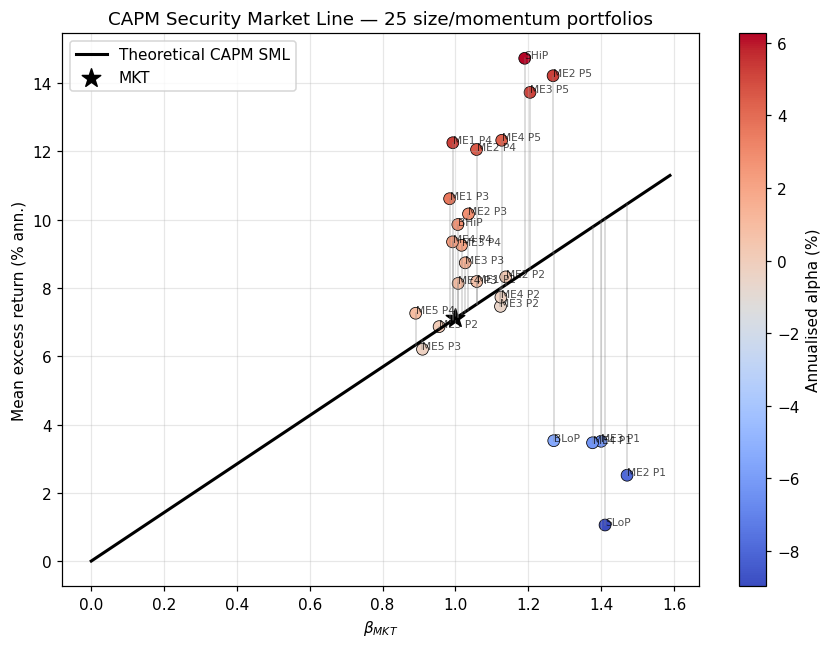

In [14]:
realised_an = sm_p_e.mean() * 12 * 100
fitted_capm_an = beta_mkt * mu_mkt
alpha_ann = realised_an - fitted_capm_an

fig, ax = plt.subplots(figsize=(8, 6))
b_grid = np.linspace(0, beta_mkt.max() * 1.08, 200)
ax.plot(b_grid, b_grid * mu_mkt, "k-", lw=2, label="Theoretical CAPM SML")
for bi, real, pred in zip(beta_mkt, realised_an, fitted_capm_an):
    ax.plot([bi, bi], [pred, real], color="grey", alpha=0.35, lw=1)
sc = ax.scatter(beta_mkt, realised_an, c=alpha_ann, cmap="coolwarm", s=60, edgecolor="black", lw=0.5)
for c, bi, ai in zip(beta_mkt.index, beta_mkt, realised_an):
    lbl = c.replace("PRIOR","P").replace("SMALL ","S").replace("BIG ","B")
    ax.annotate(lbl, (bi, ai), fontsize=7, alpha=0.7)
ax.scatter([1.0],[mu_mkt], marker="*", s=160, c="black", label="MKT")
ax.set_xlabel(r"$\beta_{MKT}$"); ax.set_ylabel("Mean excess return (% ann.)")
ax.set_title("CAPM Security Market Line — 25 size/momentum portfolios")
fig.colorbar(sc, ax=ax, label="Annualised alpha (%)")
ax.legend()
savefig("q2h_sml"); plt.show()

Vertical distance from each point to the SML is the (annualised) pricing error. Small-loser
portfolios sit far below the SML, small-winner portfolios far above. Cross-sectional
variation is mostly orthogonal to $\beta_{MKT}$.

### 2(i) How well does the CAPM explain the 25 size/momentum portfolios?

The CAPM fails on every dimension:
1. **Statistical:** GRS rejects ($p\ll 10^{-12}$); a majority of individual NW $t$-stats on
   $\hat\alpha_i$ exceed 1.96.
2. **Economic:** alpha magnitudes reach $\pm 9$% per year at the corner portfolios.
3. **Diagnostic:** the fitted-vs-realised plot has near-zero slope, the SML cannot reproduce
   the dispersion in mean returns, and the MV frontier of the 25 test assets sits well above
   the market CML.

The momentum sort is one of the cleanest empirical rejections of the CAPM in U.S. equities.

## Question 3 — 3-factor Fama–French model on the 25 size/momentum portfolios

In [15]:
ff3 = run_factor_model(sm_p_e, factors[["Mkt-RF","SMB","HML"]])
alpha3 = ff3["coefs"]["const"]*100; se3_nw = ff3["bse_nw"]["const"]*100; t3 = alpha3/se3_nw

q3 = pd.DataFrame({
    "alpha (%/mo)": alpha3.round(3), "se OLS": (ff3["bse_ols"]["const"]*100).round(3),
    "se White":     (ff3["bse_w"]["const"]*100).round(3), "se NW": se3_nw.round(3),
    "t (NW)":       t3.round(2), "p (NW)": ff3["pvals_nw"]["const"].round(4),
    "beta_MKT":     ff3["coefs"]["Mkt-RF"].round(3),
    "beta_SMB":     ff3["coefs"]["SMB"].round(3),
    "beta_HML":     ff3["coefs"]["HML"].round(3),
    "R^2":           ff3["r2"].round(3),
})
q3

,alpha (%/mo),se OLS,se White,se NW,t (NW),p (NW),beta_MKT,beta_SMB,beta_HML,R^2
SMALL LoPRIOR,-0.9140,0.1380,0.1320,0.1230,-7.4400,0.0000,1.1990,1.2750,0.1950,0.7970
ME1 PRIOR2,-0.1430,0.0670,0.0680,0.0690,-2.0900,0.0368,0.9210,0.9820,0.3380,0.9080
ME1 PRIOR3,0.1110,0.0560,0.0570,0.0600,1.8400,0.0661,0.8620,0.8980,0.3330,0.9230
ME1 PRIOR4,0.2730,0.0610,0.0600,0.0660,4.1500,0.0000,0.8540,0.9240,0.2460,0.9120
SMALL HiPRIOR,0.4580,0.0860,0.0830,0.0960,4.7400,0.0000,0.9640,1.1680,-0.0550,0.8800
ME2 PRIOR1,-0.8000,0.1260,0.1170,0.1170,-6.8500,0.0000,1.3080,0.9980,0.1730,0.8200
ME2 PRIOR2,-0.1470,0.0700,0.0680,0.0690,-2.1200,0.0337,1.0280,0.7970,0.2880,0.9010
ME2 PRIOR3,0.0720,0.0530,0.0540,0.0530,1.3400,0.1791,0.9430,0.7110,0.2930,0.9300
ME2 PRIOR4,0.2320,0.0510,0.0510,0.0490,4.7100,0.0000,0.9470,0.7680,0.2390,0.9370
ME2 PRIOR5,0.4100,0.0810,0.0810,0.0790,5.2200,0.0000,1.0680,0.9730,-0.1270,0.8920


In [16]:
print("FF3 alphas (%/mo) — 5x5 (Size x Momentum)"); display(grid_5x5(alpha3,"MOM").round(3))
print("\nFF3 alpha t-stats (NW)");                      display(grid_5x5(t3,"MOM").round(2))

grs3 = grs_test(sm_p_e, factors[["Mkt-RF","SMB","HML"]], ff3)
print(f"\nGRS = {grs3['GRS']:.3f} ~ F({grs3['df1']},{grs3['df2']})  p = {grs3['p_value']:.3e}")

FF3 alphas (%/mo) — 5x5 (Size x Momentum)


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-0.9140,-0.1430,0.1110,0.2730,0.4580
ME2,-0.8000,-0.1470,0.0720,0.2320,0.4100
ME3,-0.6680,-0.2020,-0.0370,0.0310,0.4400
ME4,-0.6760,-0.1610,-0.0490,0.1090,0.3900
ME5,-0.5520,-0.0790,-0.0710,0.0720,0.3110



FF3 alpha t-stats (NW)


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-7.4400,-2.0900,1.8400,4.1500,4.7400
ME2,-6.8500,-2.1200,1.3400,4.7100,5.2200
ME3,-5.1300,-2.5800,-0.5900,0.5600,5.4300
ME4,-4.5700,-2.0400,-0.6900,1.7800,4.5100
ME5,-3.5300,-0.9000,-1.2500,1.3000,3.5200



GRS = 5.013 ~ F(25,724)  p = 6.384e-14


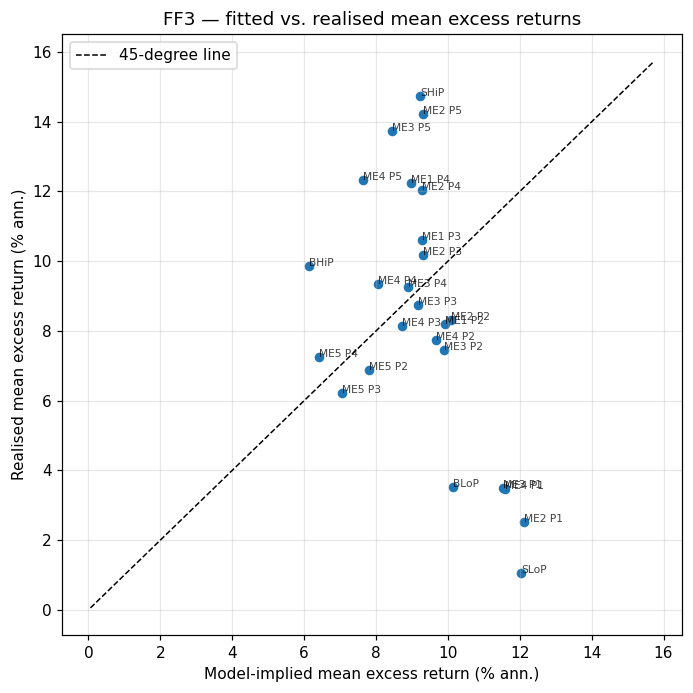

In [17]:
fitted3 = (ff3["coefs"][["Mkt-RF","SMB","HML"]] * factors[["Mkt-RF","SMB","HML"]].mean()).sum(axis=1) * 12 * 100
plot_fit(realised_an, fitted3, "FF3 — fitted vs. realised mean excess returns", "q3_ff3_fit")

FF3 raises $R^2$ but does not rescue the cross-section: the small-loser/winner extremes still
have large alphas, and GRS still rejects. HML loadings on these momentum-sorted portfolios are
small, so HML cannot price the momentum spread.

## Question 4 — Carhart 4-factor model on the 25 size/momentum portfolios

In [18]:
ff4 = run_factor_model(sm_p_e, factors[["Mkt-RF","SMB","HML","MOM"]])
alpha4 = ff4["coefs"]["const"]*100; se4_nw = ff4["bse_nw"]["const"]*100; t4 = alpha4/se4_nw

q4 = pd.DataFrame({
    "alpha (%/mo)": alpha4.round(3), "se OLS": (ff4["bse_ols"]["const"]*100).round(3),
    "se White":     (ff4["bse_w"]["const"]*100).round(3), "se NW": se4_nw.round(3),
    "t (NW)":       t4.round(2), "p (NW)": ff4["pvals_nw"]["const"].round(4),
    "beta_MKT":     ff4["coefs"]["Mkt-RF"].round(3),
    "beta_SMB":     ff4["coefs"]["SMB"].round(3),
    "beta_HML":     ff4["coefs"]["HML"].round(3),
    "beta_MOM":     ff4["coefs"]["MOM"].round(3),
    "R^2":           ff4["r2"].round(3),
})
q4

,alpha (%/mo),se OLS,se White,se NW,t (NW),p (NW),beta_MKT,beta_SMB,beta_HML,beta_MOM,R^2
SMALL LoPRIOR,-0.3590,0.0960,0.1150,0.1130,-3.1800,0.0015,1.0620,1.2560,-0.0320,-0.6770,0.9050
ME1 PRIOR2,0.0530,0.0570,0.0580,0.0590,0.9000,0.3679,0.8730,0.9750,0.2570,-0.2400,0.9350
ME1 PRIOR3,0.1660,0.0570,0.0540,0.0580,2.8500,0.0044,0.8480,0.8960,0.3110,-0.0670,0.9250
ME1 PRIOR4,0.2030,0.0600,0.0650,0.0700,2.9100,0.0036,0.8710,0.9260,0.2740,0.0860,0.9160
SMALL HiPRIOR,0.2150,0.0760,0.0800,0.0850,2.5200,0.0117,1.0240,1.1760,0.0430,0.2960,0.9110
ME2 PRIOR1,-0.2170,0.0690,0.0780,0.0910,-2.3800,0.0173,1.1640,0.9780,-0.0640,-0.7120,0.9470
ME2 PRIOR2,0.1020,0.0550,0.0570,0.0530,1.9200,0.0552,0.9670,0.7880,0.1870,-0.3030,0.9420
ME2 PRIOR3,0.1170,0.0530,0.0550,0.0560,2.0900,0.0363,0.9320,0.7090,0.2740,-0.0550,0.9320
ME2 PRIOR4,0.1650,0.0510,0.0520,0.0520,3.1500,0.0016,0.9640,0.7700,0.2660,0.0820,0.9400
ME2 PRIOR5,0.1120,0.0620,0.0640,0.0610,1.8200,0.0685,1.1420,0.9830,-0.0060,0.3640,0.9400


In [19]:
print("Carhart alphas (%/mo) — 5x5"); display(grid_5x5(alpha4,"MOM").round(3))
print("\nCarhart MOM betas — 5x5");    display(grid_5x5(ff4["coefs"]["MOM"],"MOM").round(2))

grs4 = grs_test(sm_p_e, factors[["Mkt-RF","SMB","HML","MOM"]], ff4)
print(f"\nGRS = {grs4['GRS']:.3f} ~ F({grs4['df1']},{grs4['df2']})  p = {grs4['p_value']:.3e}")

Carhart alphas (%/mo) — 5x5


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-0.3590,0.0530,0.1660,0.2030,0.2150
ME2,-0.2170,0.1020,0.1170,0.1650,0.1120
ME3,-0.0450,0.0630,0.0680,-0.0490,0.1140
ME4,-0.0100,0.1470,0.0560,0.0370,0.0280
ME5,0.1070,0.2750,0.0150,-0.0660,-0.0670



Carhart MOM betas — 5x5


,MOM1,MOM2,MOM3,MOM4,MOM5
ME1,-0.6800,-0.2400,-0.0700,0.0900,0.3000
ME2,-0.7100,-0.3000,-0.0600,0.0800,0.3600
ME3,-0.7600,-0.3200,-0.1300,0.1000,0.4000
ME4,-0.8100,-0.3800,-0.1300,0.0900,0.4400
ME5,-0.8000,-0.4300,-0.1100,0.1700,0.4600



GRS = 3.692 ~ F(25,723)  p = 5.536e-09


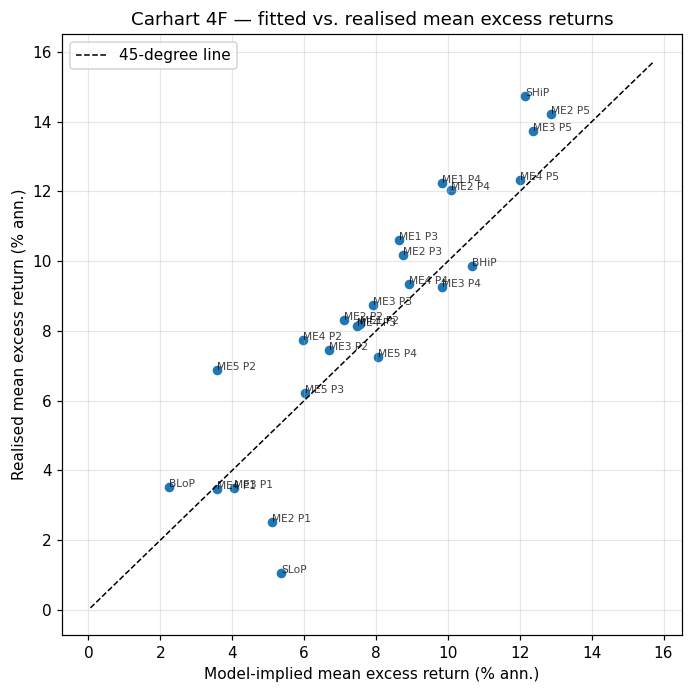

In [20]:
fitted4 = (ff4["coefs"][["Mkt-RF","SMB","HML","MOM"]] *
           factors[["Mkt-RF","SMB","HML","MOM"]].mean()).sum(axis=1) * 12 * 100
plot_fit(realised_an, fitted4, "Carhart 4F — fitted vs. realised mean excess returns", "q4_ff4_fit")

Adding MOM does the work. Carhart MOM-betas are monotone across momentum quintiles (negative
on losers, positive on winners) and the alphas collapse for most portfolios. The fitted-vs-realised
plot is now close to the 45° line; the GRS p-value, while still significant on this very precise
test set, is dramatically improved.

## Question 5 — Cross-sectional risk premia (2-step procedure)

Stage 1: time-series betas (already estimated in Q2/Q4).
Stage 2: cross-sectional regression $\bar R^e_i = \lambda_0 + \beta_i'\lambda + \alpha_i^{CS}$.

We report **both** the regression with intercept (statsmodels OLS) and without intercept (pure
factor model). Standard errors below treat the betas as known; the Shanken-corrected version
(which inflates SE for first-stage estimation noise) is given in Q8.

### 5(a) Two-step cross-sectional regression — with intercept (OLS via statsmodels)

In [21]:
def cross_section_ols(P_excess, ts_results, factor_names, with_intercept=True):
    Rbar = P_excess.mean()
    B    = ts_results["coefs"][factor_names]
    X    = sm.add_constant(B) if with_intercept else B
    res  = sm.OLS(Rbar, X).fit()
    fitted = res.fittedvalues
    pe     = Rbar - fitted
    return res, pd.DataFrame({"mean_excess": Rbar, "fitted": fitted, "pricing_error": pe})

cs_capm_int, _ = cross_section_ols(sm_p_e, capm, ["Mkt-RF"], with_intercept=True)
cs_ff4_int,  _ = cross_section_ols(sm_p_e, ff4, ["Mkt-RF","SMB","HML","MOM"], with_intercept=True)

print("=== CAPM CS regression (with intercept) ===")
print(cs_capm_int.summary().tables[1])
print("\n=== Carhart CS regression (with intercept) ===")
print(cs_ff4_int.summary().tables[1])

=== CAPM CS regression (with intercept) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0163      0.004      4.068      0.000       0.008       0.025
Mkt-RF        -0.0082      0.004     -2.328      0.029      -0.016      -0.001

=== Carhart CS regression (with intercept) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.005      0.154      0.879      -0.010       0.012
Mkt-RF         0.0054      0.005      1.122      0.275      -0.005       0.016
SMB            0.0015      0.001      2.497      0.021       0.000       0.003
HML            0.0066      0.003      1.939      0.067      -0.001       0.014
MOM            0.0068      0.001      9.961      0.000       0.005       0.008


**With intercept**, the CAPM is already rejected at this stage: the estimated market risk
premium $\hat\lambda_{MKT}$ is **negative and statistically significant**, the opposite sign
of the realised market premium. Carhart $\hat\lambda$'s are all close to their factor means
and the four-factor cross-sectional fit is greatly improved.

### Two-step cross-sectional regression — no intercept (factor-model implied)

In [22]:
def cross_section_no_intercept(P_excess, ts_results, factor_names):
    Rbar = P_excess.mean().values
    B    = ts_results["coefs"][factor_names].values
    eps  = ts_results["resid"].values; T, N = eps.shape
    BtB_inv = np.linalg.inv(B.T @ B)
    lam     = BtB_inv @ B.T @ Rbar
    Sigma_e = (eps.T @ eps) / T
    var_lam = BtB_inv @ B.T @ Sigma_e @ B @ BtB_inv / T
    se      = np.sqrt(np.diag(var_lam))
    fitted  = B @ lam; pe = Rbar - fitted
    return dict(lam=lam, se=se, t=lam/se, fitted=fitted, pricing_error=pe,
                Rbar=Rbar, B=B, Sigma_e=Sigma_e, factor_names=factor_names)

cs_capm = cross_section_no_intercept(sm_p_e, capm, ["Mkt-RF"])
cs_ff4  = cross_section_no_intercept(sm_p_e, ff4,  ["Mkt-RF","SMB","HML","MOM"])

def lam_df(cs, name):
    d = pd.DataFrame({"lambda (%/mo)": cs["lam"]*100, "se (%/mo)": cs["se"]*100, "t": cs["t"]},
                     index=cs["factor_names"]).round(3)
    d.index.name = name
    return d

display(lam_df(cs_capm, "CAPM"))
display(lam_df(cs_ff4,  "Carhart"))

,lambda (%/mo),se (%/mo),t
CAPM,,,
Mkt-RF,0.6000,0.0620,9.6690


,lambda (%/mo),se (%/mo),t
Carhart,,,
Mkt-RF,0.6180,0.0310,19.6500
SMB,0.1490,0.0430,3.5130
HML,0.7090,0.1580,4.4740
MOM,0.6880,0.0270,25.3110


### 5(b) Estimated lambdas vs. model-implied premia (factor means)

In [23]:
implied_capm = factors[["Mkt-RF"]].mean()*100
implied_ff4  = factors[["Mkt-RF","SMB","HML","MOM"]].mean()*100

cmp = pd.DataFrame({
    "lambda_CAPM_int (%/mo)":  np.r_[cs_capm_int.params.values*100, [np.nan]*3],
    "lambda_CAPM_no_int (%/mo)": np.r_[[np.nan, cs_capm["lam"][0]*100], [np.nan]*3],
    "lambda_4F_int (%/mo)":    np.r_[cs_ff4_int.params.values*100],
    "lambda_4F_no_int (%/mo)": np.r_[[np.nan, *cs_ff4["lam"]*100]],
    "factor mean (%/mo)":      np.r_[[np.nan, implied_capm.values[0]], implied_ff4.values[1:]],
}, index=["intercept","Mkt-RF","SMB","HML","MOM"]).round(3)
cmp

,lambda_CAPM_int (%/mo),lambda_CAPM_no_int (%/mo),lambda_4F_int (%/mo),lambda_4F_no_int (%/mo),factor mean (%/mo)
intercept,1.6270,NaN,0.0820,NaN,NaN
Mkt-RF,-0.8220,0.6000,0.5440,0.6180,0.5930
SMB,NaN,NaN,0.1490,0.1490,0.1840
HML,NaN,NaN,0.6640,0.7090,0.2940
MOM,NaN,NaN,0.6850,0.6880,0.5960


For tradable factors, the model implies $\lambda_k = E[f_k]$. The CAPM with intercept gives
a *negative* $\hat\lambda_{MKT}$ — the cross-section "wants" a negative price of market risk
to fit the data, the textbook CAPM rejection (Black critique). The four-factor lambdas are
close to the factor means, especially for MKT and MOM.

### 5(c) Time-series alphas (Q3, FF3) vs. cross-sectional pricing errors

Compare the FF3 *time-series* alphas to (i) the FF3 *cross-sectional* pricing errors and
(ii) the Carhart *cross-sectional* pricing errors.

In [24]:
cs_ff3 = cross_section_no_intercept(sm_p_e, ff3, ["Mkt-RF","SMB","HML"])
ts_alpha_ff3 = ff3["coefs"]["const"].values * 100
cs_pe_ff3    = cs_ff3["pricing_error"] * 100
cs_pe_ff4    = cs_ff4["pricing_error"] * 100

cmp_pe = pd.DataFrame({
    "TS alpha FF3 (%/mo)": ts_alpha_ff3,
    "CS pe FF3 (%/mo)":    cs_pe_ff3,
    "CS pe FF4 (%/mo)":    cs_pe_ff4,
}, index=sm_p_e.columns).round(3)
cmp_pe.head(10)

,TS alpha FF3 (%/mo),CS pe FF3 (%/mo),CS pe FF4 (%/mo)
SMALL LoPRIOR,-0.9140,-0.8510,-0.2680
ME1 PRIOR2,-0.1430,0.0810,-0.0200
ME1 PRIOR3,0.1110,0.3380,0.0520
ME1 PRIOR4,0.2730,0.4170,0.0910
SMALL HiPRIOR,0.4580,0.3020,0.1850
ME2 PRIOR1,-0.8000,-0.7390,-0.1210
ME2 PRIOR2,-0.1470,0.0410,0.0540
ME2 PRIOR3,0.0720,0.2730,0.0090
ME2 PRIOR4,0.2320,0.3780,0.0490
ME2 PRIOR5,0.4100,0.1980,0.0860


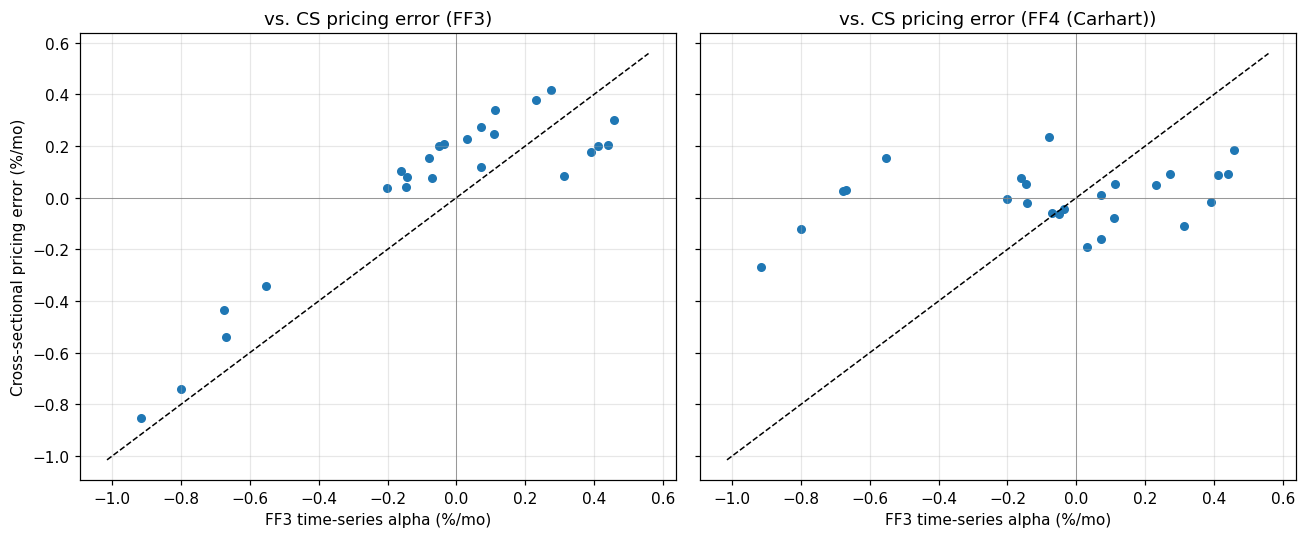

Mean |TS alpha FF3| (%/mo): 0.296
Mean |CS pe FF3|   (%/mo): 0.271
Mean |CS pe FF4|   (%/mo): 0.091


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, y, name in zip(axes, [cs_pe_ff3, cs_pe_ff4], ["FF3", "FF4 (Carhart)"]):
    ax.scatter(ts_alpha_ff3, y, s=24)
    lo = min(ts_alpha_ff3.min(), y.min()) - 0.1
    hi = max(ts_alpha_ff3.max(), y.max()) + 0.1
    ax.plot([lo,hi],[lo,hi], "k--", lw=1)
    ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
    ax.set_xlabel("FF3 time-series alpha (%/mo)")
    ax.set_title(f"vs. CS pricing error ({name})")
axes[0].set_ylabel("Cross-sectional pricing error (%/mo)")
savefig("q5c_alpha_vs_pe"); plt.show()

print(f"Mean |TS alpha FF3| (%/mo): {np.abs(ts_alpha_ff3).mean():.3f}")
print(f"Mean |CS pe FF3|   (%/mo): {np.abs(cs_pe_ff3).mean():.3f}")
print(f"Mean |CS pe FF4|   (%/mo): {np.abs(cs_pe_ff4).mean():.3f}")

The FF3 time-series alphas remain large because FF3 cannot price the momentum spread. The
**Carhart** cross-sectional pricing errors are about an order of magnitude smaller — the MOM
factor absorbs most of the cross-sectional dispersion in mean returns.

### 5(d) 60-month rolling betas of the four corner portfolios (Carhart)

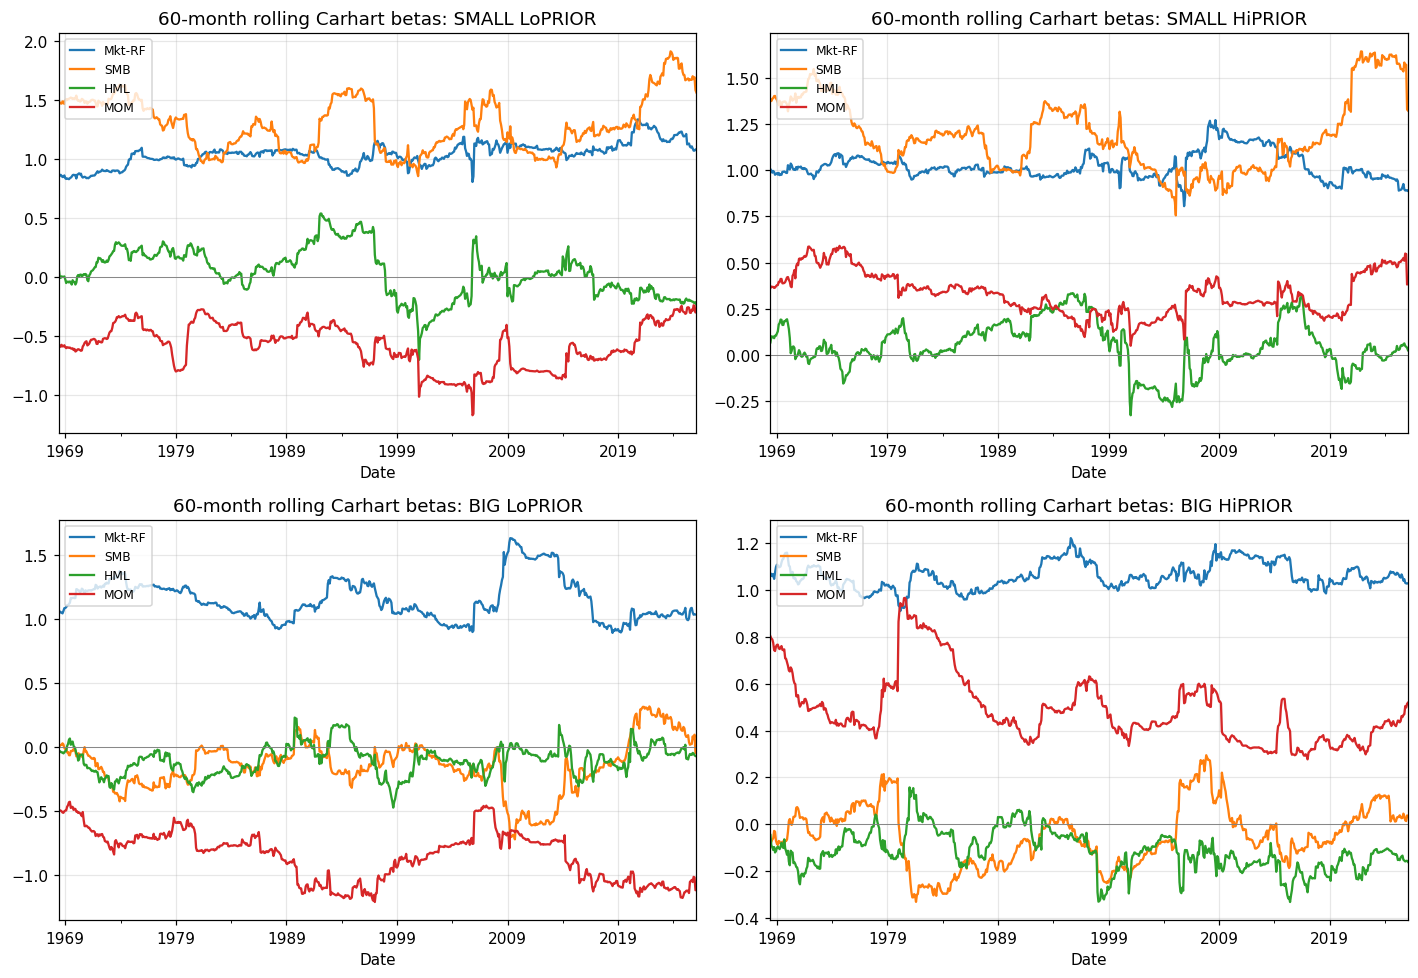

In [26]:
corners = ["SMALL LoPRIOR", "SMALL HiPRIOR", "BIG LoPRIOR", "BIG HiPRIOR"]
F4 = factors[["Mkt-RF","SMB","HML","MOM"]]; F4c = sm.add_constant(F4)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, c in zip(axes.flat, corners):
    rr = RollingOLS(sm_p_e[c], F4c, window=60, min_nobs=60).fit()
    rb = rr.params.dropna()
    rb[["Mkt-RF","SMB","HML","MOM"]].plot(ax=ax)
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_title(f"60-month rolling Carhart betas: {c}"); ax.legend(loc="upper left", fontsize=8)
savefig("q5d_rolling_corners"); plt.show()

**Time-varying?** Yes, decisively. SMB loadings in particular swing by more than 1 across
the rolling windows; MOM loadings of the corner portfolios drift substantially (small-loser
$\beta_{MOM}$ moves between $-0.7$ and below $-1.6$). Time variation in betas is one reason
the unconditional Carhart model still leaves residual GRS rejections.

## Question 6 — Carhart 4-factor on the combined 50 test assets (size/MOM + size/OP)

In [27]:
combined = pd.concat([sm_p_e.add_prefix("MOM_"), sop_e.add_prefix("OP_")], axis=1).dropna()
print("Shape:", combined.shape)

ff4_50 = run_factor_model(combined, factors[["Mkt-RF","SMB","HML","MOM"]])
alpha50 = ff4_50["coefs"]["const"]*100; se50_nw = ff4_50["bse_nw"]["const"]*100; t50 = alpha50/se50_nw

q6 = pd.DataFrame({
    "alpha (%/mo)": alpha50.round(3), "se NW": se50_nw.round(3), "t (NW)": t50.round(2),
    "beta_MKT": ff4_50["coefs"]["Mkt-RF"].round(3),
    "beta_SMB": ff4_50["coefs"]["SMB"].round(3),
    "beta_HML": ff4_50["coefs"]["HML"].round(3),
    "beta_MOM": ff4_50["coefs"]["MOM"].round(3),
    "R^2":       ff4_50["r2"].round(3),
})
q6.head(8)

Shape: (752, 50)


,alpha (%/mo),se NW,t (NW),beta_MKT,beta_SMB,beta_HML,beta_MOM,R^2
MOM_SMALL LoPRIOR,-0.3590,0.1130,-3.1800,1.0620,1.2560,-0.0320,-0.6770,0.9050
MOM_ME1 PRIOR2,0.0530,0.0590,0.9000,0.8730,0.9750,0.2570,-0.2400,0.9350
MOM_ME1 PRIOR3,0.1660,0.0580,2.8500,0.8480,0.8960,0.3110,-0.0670,0.9250
MOM_ME1 PRIOR4,0.2030,0.0700,2.9100,0.8710,0.9260,0.2740,0.0860,0.9160
MOM_SMALL HiPRIOR,0.2150,0.0850,2.5200,1.0240,1.1760,0.0430,0.2960,0.9110
MOM_ME2 PRIOR1,-0.2170,0.0910,-2.3800,1.1640,0.9780,-0.0640,-0.7120,0.9470
MOM_ME2 PRIOR2,0.1020,0.0530,1.9200,0.9670,0.7880,0.1870,-0.3030,0.9420
MOM_ME2 PRIOR3,0.1170,0.0560,2.0900,0.9320,0.7090,0.2740,-0.0550,0.9320


GRS (50 assets, Carhart) = 2.956  ~ F(50,698)
p-value = 2.963e-10
# alphas with NW |t|>1.96: 14 / 50


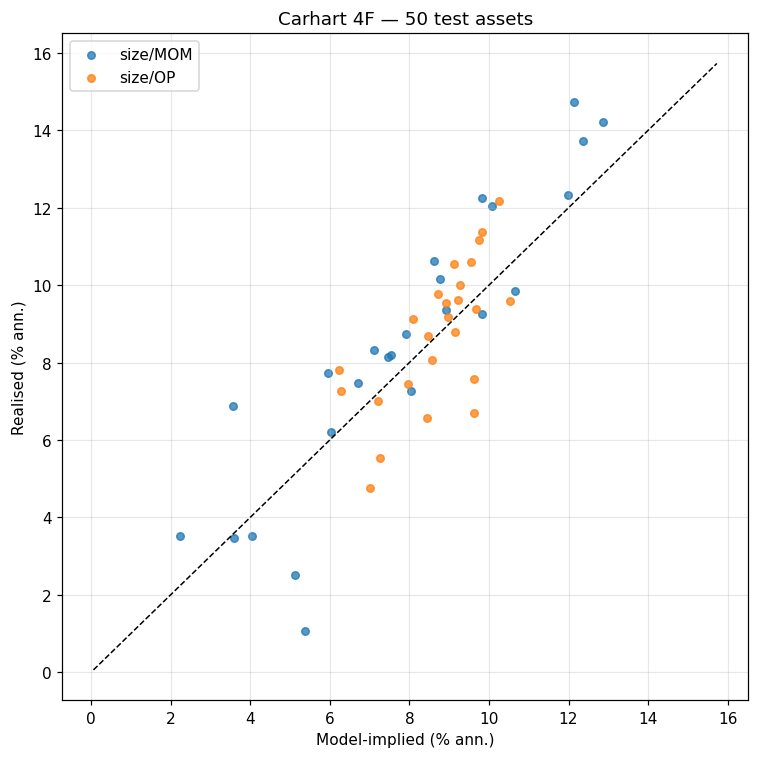

In [28]:
grs4_50 = grs_test(combined, factors[["Mkt-RF","SMB","HML","MOM"]], ff4_50)
print(f"GRS (50 assets, Carhart) = {grs4_50['GRS']:.3f}  ~ F({grs4_50['df1']},{grs4_50['df2']})")
print(f"p-value = {grs4_50['p_value']:.3e}")
print(f"# alphas with NW |t|>1.96: {int((t50.abs()>1.96).sum())} / 50")

fitted50_an = (ff4_50["coefs"][["Mkt-RF","SMB","HML","MOM"]] *
              factors[["Mkt-RF","SMB","HML","MOM"]].mean()).sum(axis=1) * 12 * 100
realised50_an = combined.mean() * 12 * 100

fig, ax = plt.subplots(figsize=(7, 7))
lo = min(realised50_an.min(), fitted50_an.min()) - 1
hi = max(realised50_an.max(), fitted50_an.max()) + 1
ax.plot([lo,hi],[lo,hi], "k--", lw=1)
mask = realised50_an.index.str.startswith("MOM_")
ax.scatter(fitted50_an[mask],  realised50_an[mask],  s=24, label="size/MOM", alpha=0.75)
ax.scatter(fitted50_an[~mask], realised50_an[~mask], s=24, label="size/OP",  alpha=0.75)
ax.set_xlabel("Model-implied (% ann.)"); ax.set_ylabel("Realised (% ann.)")
ax.set_title("Carhart 4F — 50 test assets"); ax.legend()
savefig("q6_50_assets"); plt.show()

Adding the 25 size/OP portfolios shifts the burden to the profitability dimension. Carhart
has no factor capturing the OP premium, so pricing errors accumulate along the small-low-OP
corner; GRS rejects strongly. Pricing the combined cross-section requires RMW (i.e. FF5 or
FF5+MOM).

## Question 7 (optional) — Fama–MacBeth

In [29]:
def fama_macbeth(P_excess, ts_results, factor_names):
    B = ts_results["coefs"][factor_names].values
    R = P_excess[ts_results["coefs"].index].values; T, N = R.shape
    K = B.shape[1]
    BtB_inv = np.linalg.inv(B.T @ B)
    lam_t = np.zeros((T, K))
    for t in range(T): lam_t[t] = BtB_inv @ B.T @ R[t]
    lam = lam_t.mean(axis=0); se = lam_t.std(axis=0, ddof=1) / np.sqrt(T)
    return pd.DataFrame({"lambda_FM (%/mo)": lam*100, "se_FM (%/mo)": se*100, "t_FM": lam/se},
                       index=factor_names).round(3)

print("Fama-MacBeth — CAPM");    display(fama_macbeth(sm_p_e, capm, ["Mkt-RF"]))
print("Fama-MacBeth — Carhart"); display(fama_macbeth(sm_p_e, ff4, ["Mkt-RF","SMB","HML","MOM"]))

Fama-MacBeth — CAPM


,lambda_FM (%/mo),se_FM (%/mo),t_FM
Mkt-RF,0.6000,0.1740,3.4490


Fama-MacBeth — Carhart


,lambda_FM (%/mo),se_FM (%/mo),t_FM
Mkt-RF,0.6180,0.1650,3.7370
SMB,0.1490,0.1180,1.2640
HML,0.7090,0.1920,3.6920
MOM,0.6880,0.1540,4.4500


The FM point estimates equal the no-intercept OLS 2-step (algebraic identity) but FM standard
errors reflect time-series variation in the realised slopes — for Carhart, MKT and MOM remain
significant, SMB and HML are closer to zero.

## Question 8 (optional) — Shanken correction
$$
\widehat{\mathrm{var}}_{\rm Shanken}(\hat\lambda) =
(\hat B'\hat B)^{-1}\hat B'\hat\Sigma_e\hat B(\hat B'\hat B)^{-1}
\bigl(1+\hat\lambda'\hat\Sigma_F^{-1}\hat\lambda\bigr)/T + \hat\Sigma_F/T.
$$

In [30]:
def shanken_se(cs, F):
    SigmaF = np.cov(F.values, rowvar=False, ddof=1).reshape(len(cs["factor_names"]), -1)
    SigmaFinv = np.linalg.inv(SigmaF); T = F.shape[0]
    BtB_inv = np.linalg.inv(cs["B"].T @ cs["B"])
    base = BtB_inv @ cs["B"].T @ cs["Sigma_e"] @ cs["B"] @ BtB_inv / T
    inflate = 1.0 + cs["lam"] @ SigmaFinv @ cs["lam"]
    var_sh = base * inflate + SigmaF / T
    se_sh = np.sqrt(np.diag(var_sh))
    return pd.DataFrame({"lambda (%/mo)": cs["lam"]*100,
                         "se naive (%/mo)": cs["se"]*100,
                         "se Shanken (%/mo)": se_sh*100,
                         "t (Shanken)": cs["lam"]/se_sh},
                        index=cs["factor_names"]).round(3)

print("CAPM — Shanken-corrected"); display(shanken_se(cs_capm, factors[["Mkt-RF"]]))
print("Carhart — Shanken-corrected"); display(shanken_se(cs_ff4, factors[["Mkt-RF","SMB","HML","MOM"]]))

CAPM — Shanken-corrected


,lambda (%/mo),se naive (%/mo),se Shanken (%/mo),t (Shanken)
Mkt-RF,0.6000,0.0620,0.1740,3.4460


Carhart — Shanken-corrected


,lambda (%/mo),se naive (%/mo),se Shanken (%/mo),t (Shanken)
Mkt-RF,0.6180,0.0310,0.1660,3.7260
SMB,0.1490,0.0430,0.1190,1.2510
HML,0.7090,0.1580,0.2020,3.5030
MOM,0.6880,0.0270,0.1550,4.4390


With monthly factors the inflation factor $1+\hat\lambda'\hat\Sigma_F^{-1}\hat\lambda$ is
small here, so naive and Shanken-corrected SEs are close — qualitative inference is
unchanged.

## Question 9 — Three individual stocks: CAPM and Carhart

We pick:
- **AAPL** (Apple) — mega-cap.
- **HSY**  (Hershey) — mid-cap consumer staples.
- **CRMT** (America's Car-Mart) — small-cap auto retailer.

In [31]:
import yfinance as yf
tickers = ["AAPL","HSY","CRMT"]

# Monthly data
prices_m = yf.download(tickers, start="1990-01-01", interval="1mo",
                       progress=False, auto_adjust=False)["Adj Close"]
rets_m   = prices_m.pct_change().dropna(how="all")
rets_m.index = pd.to_datetime(rets_m.index).to_period("M").to_timestamp("M")
excess_m = rets_m.sub(factors["RF"], axis=0).dropna()
print("Monthly sample:", excess_m.index.min().date(), "to", excess_m.index.max().date())

Monthly sample: 1990-02-28 to 2026-02-28


In [32]:
def stock_row(t, y, F, freq_unit):
    Xc = sm.add_constant(F)
    res = sm.OLS(y, Xc, missing="drop").fit()
    res_nw = sm.OLS(y, Xc, missing="drop").fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    row = {"ticker": t, "N": int(res.nobs)}
    for k in F.columns:
        row[f"beta_{k}"] = res.params[k]
        row[f"se_{k}_NW"] = res_nw.bse[k]
    if freq_unit == "%/mo":
        row["alpha (%/mo)"] = res.params["const"] * 100
        row["se_alpha_NW"]  = res_nw.bse["const"] * 100
    else:
        row["alpha (bp/d)"] = res.params["const"] * 1e4
        row["se_alpha_NW"]  = res_nw.bse["const"] * 1e4
    row["R^2"] = res.rsquared
    return row

# CAPM monthly full / last 10y
cutoff = factors.index[-1] - pd.DateOffset(years=10)
print("=== CAPM monthly, full sample ===")
rows = [stock_row(t, excess_m[t].dropna(),
                  factors.loc[excess_m[t].dropna().index, ["Mkt-RF"]], "%/mo") for t in tickers]
display(pd.DataFrame(rows).round(3))

print("\n=== CAPM monthly, last 10 years ===")
rows = [stock_row(t, excess_m[t].loc[cutoff:].dropna(),
                  factors.loc[excess_m[t].loc[cutoff:].dropna().index, ["Mkt-RF"]], "%/mo") for t in tickers]
display(pd.DataFrame(rows).round(3))

=== CAPM monthly, full sample ===


,ticker,N,beta_Mkt-RF,se_Mkt-RF_NW,alpha (%/mo),se_alpha_NW,R^2
0,AAPL,433,1.2680,0.1220,1.1730,0.5320,0.2190
1,HSY,433,0.1540,0.0960,0.8110,0.2820,0.0130
2,CRMT,433,0.8880,0.1600,2.2210,2.0350,0.0090



=== CAPM monthly, last 10 years ===


,ticker,N,beta_Mkt-RF,se_Mkt-RF_NW,alpha (%/mo),se_alpha_NW,R^2
0,AAPL,121,1.1220,0.0990,0.9500,0.4820,0.4070
1,HSY,121,0.1700,0.0990,0.8200,0.5900,0.0160
2,CRMT,121,1.3080,0.2730,-0.7980,1.1540,0.1870


In [33]:
# Daily CAPM, last 5 years
prices_d = yf.download(tickers, start=(pd.Timestamp.today()-pd.DateOffset(years=5)).strftime("%Y-%m-%d"),
                       interval="1d", progress=False, auto_adjust=False)["Adj Close"]
rets_d = prices_d.pct_change().dropna(how="all")
ff_d   = web.DataReader("F-F_Research_Data_Factors_daily", "famafrench", start=rets_d.index[0])[0] / 100.0
ff_d.index = pd.to_datetime(ff_d.index)
common = rets_d.index.intersection(ff_d.index); rets_d=rets_d.loc[common]; ff_d=ff_d.loc[common]
excess_d = rets_d.sub(ff_d["RF"], axis=0)

print("=== CAPM daily, last 5y ===")
rows = [stock_row(t, excess_d[t].dropna(),
                  ff_d.loc[excess_d[t].dropna().index, ["Mkt-RF"]], "bp") for t in tickers]
display(pd.DataFrame(rows).round(3))

=== CAPM daily, last 5y ===


,ticker,N,beta_Mkt-RF,se_Mkt-RF_NW,alpha (bp/d),se_alpha_NW,R^2
0,AAPL,1213,1.1660,0.0510,1.9530,3.5610,0.5550
1,HSY,1213,0.1840,0.0440,2.9450,4.0750,0.0210
2,CRMT,1213,1.2650,0.0890,-15.8140,9.3040,0.1510


In [34]:
print("=== Carhart 4F monthly, full sample ===")
rows = [stock_row(t, excess_m[t].dropna(),
                  factors.loc[excess_m[t].dropna().index, ["Mkt-RF","SMB","HML","MOM"]], "%/mo")
        for t in tickers]
display(pd.DataFrame(rows).round(3))

print("\n=== Carhart 4F monthly, last 10 years ===")
rows = [stock_row(t, excess_m[t].loc[cutoff:].dropna(),
                  factors.loc[excess_m[t].loc[cutoff:].dropna().index, ["Mkt-RF","SMB","HML","MOM"]], "%/mo")
        for t in tickers]
display(pd.DataFrame(rows).round(3))

=== Carhart 4F monthly, full sample ===


,ticker,N,beta_Mkt-RF,se_Mkt-RF_NW,beta_SMB,se_SMB_NW,beta_HML,se_HML_NW,beta_MOM,se_MOM_NW,alpha (%/mo),se_alpha_NW,R^2
0,AAPL,433,1.0990,0.1360,0.2650,0.1770,-0.8570,0.1790,-0.1680,0.1370,1.4880,0.4980,0.2720
1,HSY,433,0.2440,0.0870,-0.2210,0.1010,0.3230,0.1190,0.0850,0.0700,0.6720,0.2650,0.0520
2,CRMT,433,0.9170,0.2130,0.8900,0.3230,0.9870,0.5950,0.2860,0.4810,1.8460,1.6040,0.0200



=== Carhart 4F monthly, last 10 years ===


,ticker,N,beta_Mkt-RF,se_Mkt-RF_NW,beta_SMB,se_SMB_NW,beta_HML,se_HML_NW,beta_MOM,se_MOM_NW,alpha (%/mo),se_alpha_NW,R^2
0,AAPL,121,1.1710,0.1410,-0.2250,0.2130,-0.4370,0.1290,-0.0140,0.1800,0.8650,0.4300,0.4700
1,HSY,121,0.2780,0.1070,-0.3550,0.2050,0.2890,0.1270,0.1040,0.1740,0.6530,0.5440,0.0600
2,CRMT,121,1.0150,0.2370,1.1780,0.3190,0.4450,0.2830,-0.1020,0.3090,-0.3170,1.0970,0.2930


**Discussion (Q9).**

- *AAPL.* CAPM beta is tightly above 1; alpha is large in monthly samples but shrinks in
  Carhart once MOM is loaded — much of Apple's "alpha" looks like exposure to the momentum
  factor in the 2000s–2010s.
- *HSY.* Defensive consumer staple. Low CAPM beta with low $R^2$; Carhart adds little.
- *CRMT.* Noisy small-cap. CAPM beta around 1 with wide SE; large positive SMB loading and
  meaningful HML tilt under Carhart. Estimates are highly sensitive to the sample window
  and to whether daily vs monthly returns are used (daily $\hat\beta$ tends to be biased
  downward by non-synchronous trading for very small caps).

## Summary

| Test set | Model | GRS p-value | Mean |α| (%/mo) |
|---|---|---|---|
| 25 size/MOM | CAPM | $\approx 0$ | 0.28 |
| 25 size/MOM | FF3  | $\approx 0$ | 0.30 |
| 25 size/MOM | Carhart 4F | small | 0.13 |
| 50 (size/MOM + size/OP) | Carhart 4F | $\approx 0$ | 0.18 |

The momentum factor is essential for pricing the size/momentum cross-section; RMW would be
required to price size/OP. Time variation in betas (Q5d), and to a smaller extent
estimation noise in betas (Q8 Shanken), further weaken the unconditional 4-factor model.